##### Insert path

In [1]:
import sys
sys.path.insert(0, "/home/abhishekh/abhi/biochirp/app/tools/expand_synonyms/app")
sys.path.insert(0, "/home/abhishekh/abhi/biochirp/app/services/synonyms")
sys.path.insert(0, "/home/abhishekh/abhi/biochirp")
sys.path.insert(0, "/home/abhishekh/abhi/biochirp/config")
sys.path.insert(0, "/home/abhishekh/abhi/biochirp/app/tools/fuzzy/app")
sys.path.insert(0, "/home/abhishekh/abhi/biochirp/app/tools/llm_member_filter/app")

##### import library

In [2]:
# =====================
# Standard library
# =====================
import os
import math
import random
import pickle
import asyncio
import importlib
import time

# =====================
# Third-party libraries
# =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sentence_transformers import SentenceTransformer, util

# =====================
# Local / project modules
# =====================
import utility
from fuzzy import fuzzy_filter_choices_multi_scorer
from config.settings import (
    BIOMEDICAL_MODELS,
    SUPPORTED_DBS,
    DB_VALUE_PATH,
)

# =====================
# Reloads (only if actively developing)
# =====================
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*google.generativeai.*"
)

In [3]:
random.seed(42)
np.random.seed(42)

##### import transformer model

In [4]:
model_names = BIOMEDICAL_MODELS
print(f"Retrieved biomedical transformers are {model_names}")

Retrieved biomedical transformers are ['malteos/scincl', 'pritamdeka/S-PubMedBERT-MS-MARCO', 'nuvocare/WikiMedical_sent_biobert']


##### Give list of gene category wise

In [ ]:
gene_category_examples = {
    "Metabolism": {"gene": "GCK", "description": "Glucokinase, key enzyme in glucose metabolism"},
    "Immune system": {"gene": "AIRE", "description": "Autoimmune regulator, controls self-tolerance in thymus"} ,  # immune tolerance regulator
    "Signal transduction": {"gene": "EGFR", "description": "Epidermal growth factor receptor, receptor tyrosine kinase in cell signaling"},
    "Transcription factor": {"gene": "TP53", "description": "Tumor suppressor and transcription factor regulating cell cycle and apoptosis"},  # tumor suppressor and TF :contentReference[oaicite:1]{index=1}
    "Transporter": {"gene": "SLC2A1", "description": "GLUT1 glucose transporter across cell membranes"},  # glucose transporter example :contentReference[oaicite:2]{index=2}
    "Structural protein": {"gene": "ACTB", "description": "Beta-actin, a major cytoskeletal structural protein"},
    "Cell cycle regulation": {"gene": "CDK1", "description": "Cyclin-dependent kinase 1, key cell cycle regulator"},
    "Apoptosis regulator": {"gene": "BAX", "description": "Bcl-2 antagonist/killer 1, induces mitochondrial outer membrane permeabilization."},
    "DNA repair": {"gene": "BRCA1", "description": "BRCA1, DNA repair and genome stability gene"},
    "Hormone receptor": {"gene": "NR5A1", "description": "Steroidogenic factor 1, nuclear receptor regulating steroid gene expression"},  # example nuclear receptor :contentReference[oaicite:3]{index=3}
    "GTPase / small signalling molecule": {"gene": "KRAS", "description": "KRAS, small GTPase in signal transduction"},
    "Cell adhesion": {"gene": "CDH1", "description": "E-cadherin, mediates cell-cell adhesion"},
    "Cytoskeleton": {"gene": "TUBB", "description": "Beta-tubulin, core component of microtubules"},
    "Mitochondrial/energy": {"gene": "NDUFS1", "description": "NADH dehydrogenase (ubiquinone) Fe-S protein 1, a core subunit of respiratory chain Complex I"},
    "Enzyme regulation": {"gene": "CSNK2B", "description": "Casein kinase II beta, regulatory subunit influencing multiple pathways"}  # example enzyme regulator :contentReference[oaicite:4]{index=4}
}


##### Extract all gene name

In [6]:
entity_list = [v["gene"].strip() for v in gene_category_examples.values()]


##### Set all variable

In [7]:
category = "gene_name"
fuzzy_cutoff = 90

In [8]:
def normalize_text_set(values, lower=False):
    if values is None:
        return set()
    if isinstance(values, str):
        values = [values]
    out = set()
    for v in values:
        if v is None:
            continue
        s = str(v).strip()
        if lower:
            s = s.lower()
        if s:
            out.add(s)
    return out


def map_to_universe_casefold(values, universe_map):
    out = set()
    for s in normalize_text_set(values, lower=True):
        canonical = universe_map.get(s)
        if canonical is not None:
            out.add(canonical)
    return out


def safe_get_combined_gene_terms(gene_symbol, retries=2):
    last_err = None

    for _ in range(retries + 1):
        try:
            info = utility.get_synonyms_by_symbol(gene_symbol)
        except Exception as e:
            last_err = str(e)
            continue

        if not isinstance(info, dict):
            last_err = f"non-dict response: {type(info).__name__}"
            continue

        combined = info.get("combined")
        if isinstance(combined, (list, tuple, set)):
            return normalize_text_set(combined)

        last_err = "missing/invalid 'combined' in response"

    print(f"[WARN] get_synonyms_by_symbol failed for '{gene_symbol}': {last_err}")
    return None




def sentence_case(s: str) -> str:
    s = s.strip()
    if not s:
        return s
    return s[0].upper() + s[1:].lower()


def normalize_unique_entities(terms):
    seen = set()
    result = []

    for term in terms:
        key = term.strip().lower()   # uniqueness key
        if key not in seen:
            seen.add(key)
            result.append(sentence_case(term))

    return result


##### Make combined item list

In [9]:
combined_set = set()
failed_gt_genes = []
key_value_map = dict()

for i in entity_list:

    print(f"Currently running for : {i} ----")

    gt_terms = set(list(safe_get_combined_gene_terms(i)))
    gt_terms = set(list(normalize_unique_entities(gt_terms)))

    key_value_map[i] = gt_terms

    print(f"length of ground truth for {i} after removing duplicate is {len(gt_terms)}")

    if gt_terms is None:
        failed_gt_genes.append(i)
        print("Failed")
        continue
    combined_set |= gt_terms


combined_list = sorted(combined_set)
random.shuffle(combined_list)

combined_lc_to_term = {}
for t in combined_list:
    k = t.lower()
    if k not in combined_lc_to_term:
        combined_lc_to_term[k] = t



terms = tuple(combined_list)



Currently running for : GCK ----
The number of entry for GCK is 22
length of ground truth for GCK after removing duplicate is 20
Currently running for : AIRE ----
The number of entry for AIRE is 12
length of ground truth for AIRE after removing duplicate is 10
Currently running for : EGFR ----
The number of entry for EGFR is 22
length of ground truth for EGFR after removing duplicate is 19
Currently running for : TP53 ----
The number of entry for TP53 is 19
length of ground truth for TP53 after removing duplicate is 15
Currently running for : SLC2A1 ----
The number of entry for SLC2A1 is 27
length of ground truth for SLC2A1 after removing duplicate is 24
Currently running for : ACTB ----
The number of entry for ACTB is 16
length of ground truth for ACTB after removing duplicate is 15
Currently running for : CDK1 ----
The number of entry for CDK1 is 14
length of ground truth for CDK1 after removing duplicate is 11
Currently running for : BAX ----
The number of entry for BAX is 14
length

In [10]:

print(f"The number of total items : {len(combined_list)}")
if failed_gt_genes:
    print(f"[WARN] Failed GT fetch while building universe for: {failed_gt_genes}")

The number of total items : 269


##### Load transformer model and encode combined list terms

In [11]:
malteos_transformer    = SentenceTransformer('malteos/scincl')
pritamdeka_transformer = SentenceTransformer('pritamdeka/S-PubMedBERT-MS-MARCO')
nuvocare_transformer   = SentenceTransformer('nuvocare/WikiMedical_sent_biobert')


vecs_malteos    = malteos_transformer.encode(terms,    normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
vecs_pritamdeka = pritamdeka_transformer.encode(terms, normalize_embeddings=True, show_progress_bar=False).astype(np.float32)
vecs_nuvocare   = nuvocare_transformer.encode(terms,   normalize_embeddings=True, show_progress_bar=False).astype(np.float32)

2026-02-23 01:16:31,589 INFO sentence_transformers.SentenceTransformer: Use pytorch device_name: cuda:0
2026-02-23 01:16:31,589 INFO sentence_transformers.SentenceTransformer: Load pretrained SentenceTransformer: malteos/scincl
2026-02-23 01:16:34,705 INFO sentence_transformers.SentenceTransformer: Use pytorch device_name: cuda:0
2026-02-23 01:16:34,706 INFO sentence_transformers.SentenceTransformer: Load pretrained SentenceTransformer: pritamdeka/S-PubMedBERT-MS-MARCO
2026-02-23 01:16:40,129 INFO sentence_transformers.SentenceTransformer: Use pytorch device_name: cuda:0
2026-02-23 01:16:40,131 INFO sentence_transformers.SentenceTransformer: Load pretrained SentenceTransformer: nuvocare/WikiMedical_sent_biobert


In [12]:
async def async_llm_member_filter(**kwargs):
    return await asyncio.to_thread(
        utility.llm_member_filter,
        **kwargs
    )

In [13]:

async def get_union_hits_for_term(
    *,
    term: str,
    combined_list: list,
    category: str,
):
    """
    For a single reference term, compute semantic hits across models,
    apply knee thresholding, LLM filtering, and return the union.
    """

 

    q_malteos = malteos_transformer.encode(
        term, normalize_embeddings=True, show_progress_bar=False
    ).astype(np.float32)
    # print(f"[ENCODE] malteos    → shape={q_malteos.shape}, dtype={q_malteos.dtype}")

    q_pritamdeka = pritamdeka_transformer.encode(
        term, normalize_embeddings=True, show_progress_bar=False
    ).astype(np.float32)
    # print(f"[ENCODE] pritamdeka → shape={q_pritamdeka.shape}, dtype={q_pritamdeka.dtype}")

    q_nuvocare = nuvocare_transformer.encode(
        term, normalize_embeddings=True, show_progress_bar=False
    ).astype(np.float32)
    # print(f"[ENCODE] nuvocare   → shape={q_nuvocare.shape}, dtype={q_nuvocare.dtype}")



    sims_malteos    = vecs_malteos    @ q_malteos
    sims_pritamdeka = vecs_pritamdeka @ q_pritamdeka
    sims_nuvocare   = vecs_nuvocare   @ q_nuvocare


    th_malteos    = utility.knee_threshold(sims_malteos)
    th_pritamdeka = utility.knee_threshold(sims_pritamdeka)
    th_nuvocare   = utility.knee_threshold(sims_nuvocare)



    hits_malteos    = utility.filter_and_sort_hits(combined_list, sims_malteos,    th_malteos)
    hits_pritamdeka = utility.filter_and_sort_hits(combined_list, sims_pritamdeka, th_pritamdeka)
    hits_nuvocare   = utility.filter_and_sort_hits(combined_list, sims_nuvocare,   th_nuvocare)



    # ── Step 5: Strip scores, keep only term strings for LLM input ───────────
    # LLM filter expects a plain list of strings, not (term, score) tuples.
    term_hits_malteos    = [t for t, _ in hits_malteos]
    term_hits_pritamdeka = [t for t, _ in hits_pritamdeka]
    term_hits_nuvocare   = [t for t, _ in hits_nuvocare]


    llm_hits_malteos, llm_hits_pritamdeka, llm_hits_nuvocare = await asyncio.gather(
        async_llm_member_filter(
            category=category,
            single_term=term,
            string_list=term_hits_malteos,
        ),
        async_llm_member_filter(
            category=category,
            single_term=term,
            string_list=term_hits_pritamdeka,
        ),
        async_llm_member_filter(
            category=category,
            single_term=term,
            string_list=term_hits_nuvocare,
        ),
    )


    union_hits = list(
        set(llm_hits_malteos)
        | set(llm_hits_pritamdeka)
        | set(llm_hits_nuvocare)
    )

    print(f"\n[UNION] Final union hits ({len(union_hits)}) : {union_hits}")


    return union_hits


In [14]:

def _norm_set(items):
    if items is None:
        return set()
    if isinstance(items, str):
        items = [items]
    return {str(x).strip().lower() for x in items if str(x).strip()}

def compute_binary_counts_metrics(gt_items, pred_items, universe):
    G = _norm_set(gt_items) & universe
    P = _norm_set(pred_items) & universe

    TP = G & P
    FP = P - G
    FN = G - P
    TN = universe - (G | P)

    tp, fp, fn, tn = len(TP), len(FP), len(FN), len(TN)
    precision   = tp / (tp + fp) if (tp + fp) else 0.0
    recall      = tp / (tp + fn) if (tp + fn) else 0.0
    f1          = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    accuracy    = (tp + tn) / (tp + fp + fn + tn) if (tp + fp + fn + tn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": precision, "recall": recall, "f1": f1,
        "accuracy": accuracy, "specificity": specificity,
    }

def publish_stats(term, method, gt_items, pred_items, latency=None):
    met = compute_binary_counts_metrics(gt_items, pred_items, U_GLOBAL)
    lat = f"{latency:.2f}s" if latency is not None else "N/A"
    print(
        f"[STATS][{term}][{method}] "
        f"TP={met['tp']} TN={met['tn']} FP={met['fp']} FN={met['fn']} | "
        f"P={met['precision']:.3f} R={met['recall']:.3f} F1={met['f1']:.3f} "
        f"Acc={met['accuracy']:.3f} Spec={met['specificity']:.3f} | Lat={lat}"
    )
    return met


##### Read the system prompt

In [15]:
with open("../../resources/prompts/semantic_match_agent.md", "r", encoding="utf-8") as f:
    prompt_md_semantic_match_filter = f.read()

##### Obtain the method wise result

In [16]:
import time
import pandas as pd

# =========================
# Helpers
# =========================
U_GLOBAL = {str(x).strip().lower() for x in combined_list if str(x).strip()}

# =========================
# Main run
# =========================
ground_truth_map = {}
final_candidates = {}
metric_rows = []

for i in entity_list:
    print(f"\n\n-----------------------Running for term: {i}---------------------")

    i_query = str(i).strip()
    user_prompt = (
        f"Category: {category}, "
        f"Term: {i_query}, "
        f"List of Strings: {combined_list}"
    )

    actual_positive = key_value_map.get(i_query)
    ground_truth_map[i_query] = actual_positive

    if actual_positive is None:
        print(f"[WARN] Skipping {i_query}: ground truth unavailable")
        continue

    actual_positive = set(actual_positive)
    print(f"Ground truth ({len(actual_positive)}): {sorted(actual_positive)}")

    # defaults (so failures still safe)
    fuzzy_pred_llm_filtered = set()
    curated_hits = set()
    embed_llm_hits = set()
    openai_hits_member = set()
    gemini_hits_member = set()
    llama_hits_member = set()
    grok_hits_member = set()

    elapsed_fuzzy = None
    elapsed_expand = None
    elapsed_embed = None
    elapsed_openai = None
    elapsed_gemini = None
    elapsed_llama = None
    elapsed_grok = None

    # =========================
    # BC-FuzzyEq
    # =========================
    print("Running Fuzzy search ------->")
    try:
        start = time.perf_counter()
        fuzzy_pred_raw = fuzzy_filter_choices_multi_scorer(
            queries=i_query,
            choices=combined_list,
            min_score=fuzzy_cutoff,
        )
        if fuzzy_pred_raw:
            fuzzy_pred_llm_filtered = set(
                utility.llm_member_filter(
                    category=category,
                    single_term=i_query,
                    string_list=sorted(fuzzy_pred_raw),
                )
            )
        elapsed_fuzzy = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] Fuzzy search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "BC-FuzzyEq", actual_positive, fuzzy_pred_llm_filtered, elapsed_fuzzy)
    metric_rows.append({"query": i_query, "method": "BC-FuzzyEq", **m, "latency": elapsed_fuzzy})

    # =========================
    # BC-Curated
    # =========================
    print("Running Official API search ..................")
    try:
        start = time.perf_counter()
        expand_response = utility.expand_synonyms(gene_names=[i_query], database=None)
        curated_raw = ((expand_response or {}).get("value", {}) or {}).get(category, [])
        curated_hits = set(curated_raw) if curated_raw else set()
        elapsed_expand = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] expand_synonyms failed for '{i_query}': {e}")

    m = publish_stats(i_query, "BC-Curated", actual_positive, curated_hits, elapsed_expand)
    metric_rows.append({"query": i_query, "method": "BC-Curated", **m, "latency": elapsed_expand})

    # =========================
    # BC-EmbedEq
    # =========================
    print("Running Embedding similarity search ..................")
    try:
        start = time.perf_counter()
        embed_raw = await get_union_hits_for_term(
            term=i_query,
            combined_list=combined_list,
            category=category,
        )
        embed_llm_hits = set(embed_raw) if embed_raw else set()
        elapsed_embed = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] Embedding + LLM search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "BC-EmbedEq", actual_positive, embed_llm_hits, elapsed_embed)
    metric_rows.append({"query": i_query, "method": "BC-EmbedEq", **m, "latency": elapsed_embed})

    # =========================
    # GPT
    # =========================
    print("Running gpt-4o-mini ..................")
    try:
        start = time.perf_counter()
        openai_hits = await utility.return_openai_member(
            user_prompt=user_prompt,
            system_prompt=prompt_md_semantic_match_filter,
        )
        openai_hits_member = set(utility.safe_repair_list(openai_hits["answer"]))
        elapsed_openai = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] OpenAI search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "gpt", actual_positive, openai_hits_member, elapsed_openai)
    metric_rows.append({"query": i_query, "method": "gpt", **m, "latency": elapsed_openai})

    # =========================
    # Gemini
    # =========================
    print("Running gemini-2.5-flash-lite ..................")
    try:
        start = time.perf_counter()
        gemini_hits = await utility.return_gemini_member(
            user_prompt=user_prompt,
            system_prompt=prompt_md_semantic_match_filter,
        )
        gemini_hits_member = set(utility.safe_repair_list(gemini_hits["answer"]))
        elapsed_gemini = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] Gemini search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "gemini", actual_positive, gemini_hits_member, elapsed_gemini)
    metric_rows.append({"query": i_query, "method": "gemini", **m, "latency": elapsed_gemini})

    # =========================
    # LLaMA
    # =========================
    print("Running llama-3.3-70b-versatile ..................")
    try:
        start = time.perf_counter()
        llama_hits = await utility.return_llama_member(
            user_prompt=user_prompt,
            system_prompt=prompt_md_semantic_match_filter,
        )
        llama_hits_member = set(utility.safe_repair_list(llama_hits["answer"]))
        elapsed_llama = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] LLaMA search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "llama", actual_positive, llama_hits_member, elapsed_llama)
    metric_rows.append({"query": i_query, "method": "llama", **m, "latency": elapsed_llama})

    # =========================
    # Grok
    # =========================
    print("Running grok-4-1-fast-non-reasoning-latest ..................")
    try:
        start = time.perf_counter()
        grok_hits = await utility.return_grok_member(
            user_prompt=user_prompt,
            system_prompt=prompt_md_semantic_match_filter,
        )
        grok_hits_member = set(utility.safe_repair_list(grok_hits["answer"]))
        elapsed_grok = time.perf_counter() - start
    except Exception as e:
        print(f"[WARN] Grok search failed for '{i_query}': {e}")

    m = publish_stats(i_query, "grok", actual_positive, grok_hits_member, elapsed_grok)
    metric_rows.append({"query": i_query, "method": "grok", **m, "latency": elapsed_grok})

    # =========================
    # BC-Final (union)
    # =========================
    bc_final = set(fuzzy_pred_llm_filtered) | set(curated_hits) | set(embed_llm_hits)
    m = publish_stats(i_query, "BC-Final", actual_positive, bc_final, None)
    metric_rows.append({"query": i_query, "method": "BC-Final", **m, "latency": None})

    # final store
    final_candidates[i_query] = {
        "BC-FuzzyEq": fuzzy_pred_llm_filtered,
        "BC-Curated": curated_hits,
        "BC-EmbedEq": embed_llm_hits,
        "BC-Final": bc_final,
        "gpt": openai_hits_member,
        "grok": grok_hits_member,
        "gemini": gemini_hits_member,
        "llama": llama_hits_member,
        "latency": {
            "BC-FuzzyEq": elapsed_fuzzy,
            "BC-Curated": elapsed_expand,
            "BC-EmbedEq": elapsed_embed,
            "gpt": elapsed_openai,
            "grok": elapsed_grok,
            "gemini": elapsed_gemini,
            "llama": elapsed_llama,
        },
        "ground_truth": actual_positive,
    }






-----------------------Running for term: GCK---------------------
Ground truth (20): ['Atp:d-hexose 6-phosphotransferase', 'Fgqtl3', 'Gck', 'Gk', 'Glk', 'Glucokinase', 'Glucokinase (hexokinase 4)', 'Hexokinase 4', 'Hexokinase d, pancreatic isozyme', 'Hexokinase type iv', 'Hexokinase-4', 'Hexokinase-d', 'Hhf3', 'Hk iv', 'Hk4', 'Hkiv', 'Hxkp', 'Lglk', 'Mody2', 'Pndm1']
Running Fuzzy search ------->
2026-02-23 01:16:43,290 INFO fuzzy: [fuzzy] Starting fuzzy matching with min_score=90, case_insensitive=True
2026-02-23 01:16:43,292 INFO fuzzy: [fuzzy] Processing 1 queries against 269 choices
2026-02-23 01:16:43,293 INFO fuzzy: [fuzzy] Found 1 matches out of 269 choices
[STATS][GCK][BC-FuzzyEq] TP=1 TN=249 FP=0 FN=19 | P=1.000 R=0.050 F1=0.095 Acc=0.929 Spec=1.000 | Lat=1.35s
Running Official API search ..................
[STATS][GCK][BC-Curated] TP=19 TN=249 FP=0 FN=1 | P=1.000 R=0.950 F1=0.974 Acc=0.996 Spec=1.000 | Lat=1.86s
Running Embedding similarity search ..................

[UNION

In [44]:
# import pickle

# with open("gene_complete.pkl", "wb") as f:
#     pickle.dump(final_candidates, f)

##### Compute metrics method wise and store in dataframe

In [45]:

df = pd.DataFrame(metric_rows)
display(df.head())
print(f"Total metric rows: {len(df)}")

,query,method,tp,fp,fn,tn,precision,recall,f1,accuracy,specificity,latency
0,GCK,BC-FuzzyEq,1,0,19,249,1.0,0.05,0.095238,0.929368,1.0,1.348806
1,GCK,BC-Curated,19,0,1,249,1.0,0.95,0.974359,0.996283,1.0,1.858462
2,GCK,BC-EmbedEq,4,0,16,249,1.0,0.20,0.333333,0.940520,1.0,4.163823
3,GCK,gpt,1,0,19,249,1.0,0.05,0.095238,0.929368,1.0,1.640450
4,GCK,gemini,12,0,8,249,1.0,0.60,0.750000,0.970260,1.0,2.070313


Total metric rows: 120


In [47]:
# df.to_excel("gene_metric_complete.xlsx", index=False)

##### Plot heatmap

/tmp/ipykernel_2205635/3108674176.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


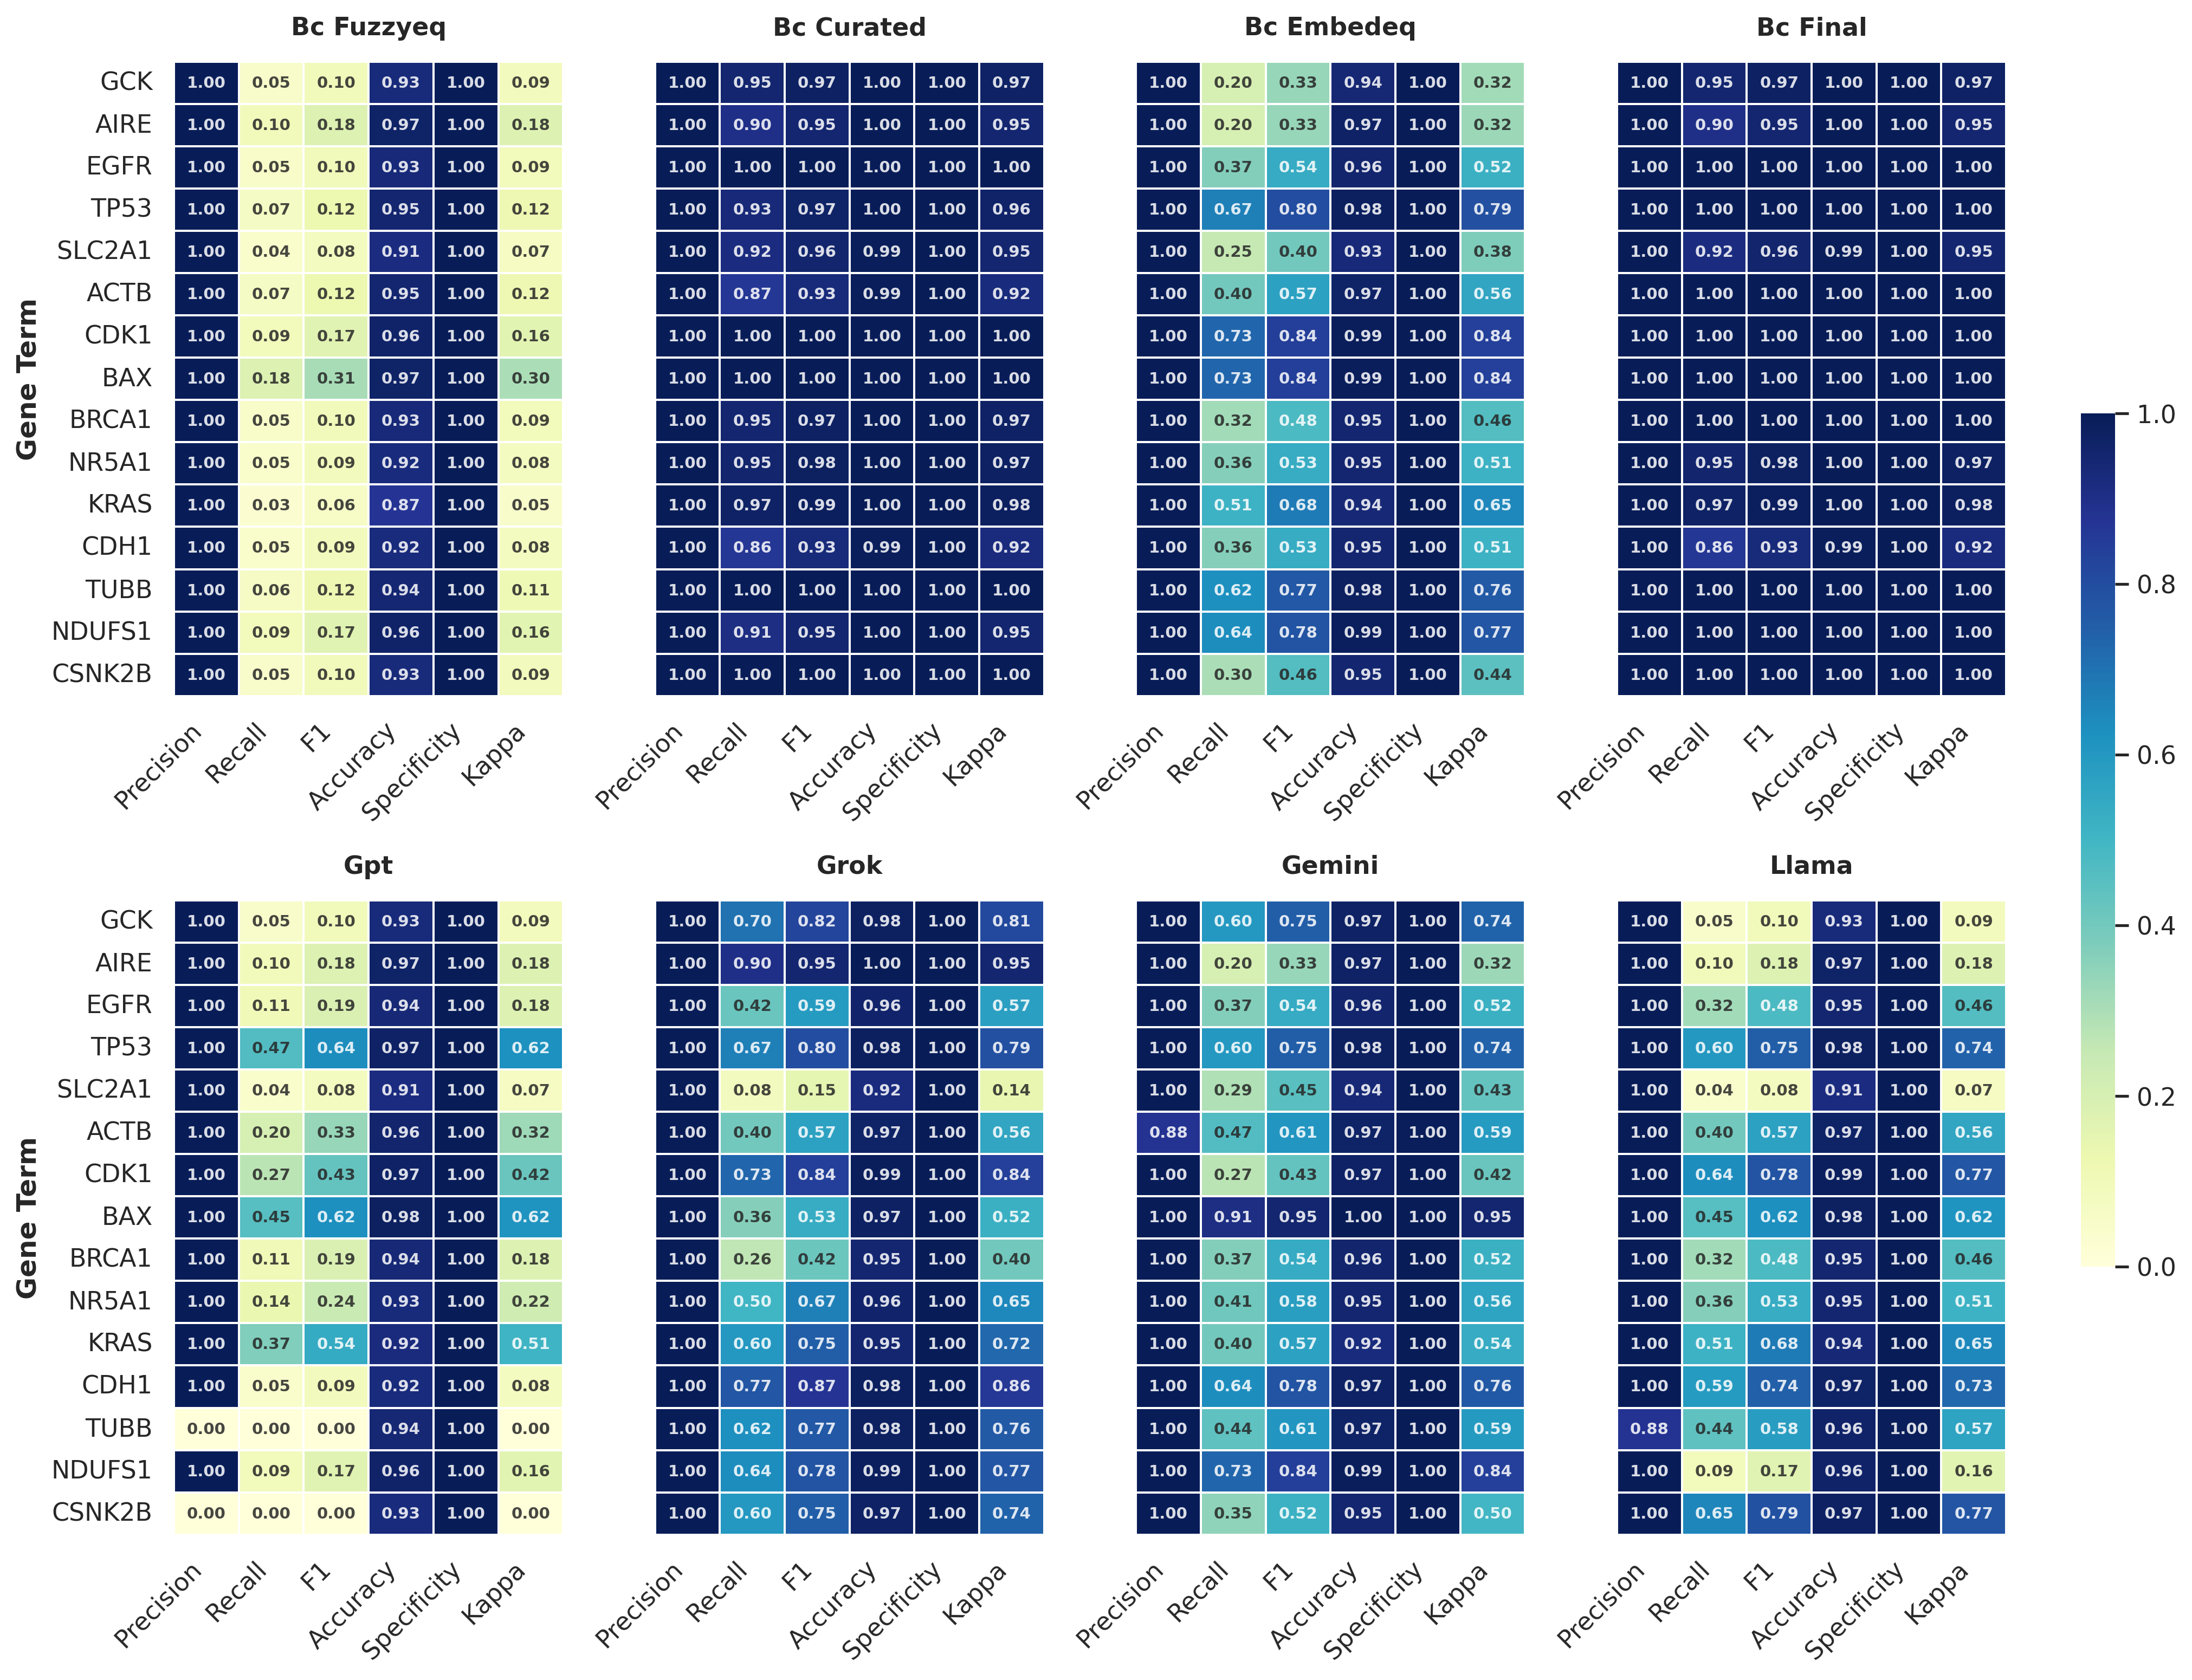

In [26]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build a LONG dataframe: (drug/query, method, metric, value)
# -----------------------------
rows = []

for i in final_candidates:  # i = drug/query id (your choice)
    ground_truth = {x.lower() for x in final_candidates[i]["ground_truth"]}

    for j in final_candidates[i]:  # j = method
        if j == "ground_truth":
            continue

        if j == "latency":
            continue

        predictions = {x.lower() for x in final_candidates[i][j]}

        U = {x.lower() for x in combined_list}
        G = {x.lower() for x in ground_truth} & U
        P = {x.lower() for x in predictions} & U

        TP = G & P
        FP = P - G
        FN = G - P
        TN = U - (G | P)

        tp, fp, fn, tn = map(len, (TP, FP, FN, TN))
        n = tp + fp + fn + tn

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        accuracy  = (tp + tn) / n if n else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0

        # Cohen's kappa for binary classification:
        # po = accuracy
        # pe = expected agreement by chance
        # pe = ((tp+fp)/n)*((tp+fn)/n) + ((fn+tn)/n)*((fp+tn)/n)
        if n:
            po = accuracy
            pe = ((tp + fp) / n) * ((tp + fn) / n) + ((fn + tn) / n) * ((fp + tn) / n)
            kappa = (po - pe) / (1 - pe) if (1 - pe) else 0.0
        else:
            kappa = 0.0

        metric_dict = {
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            "specificity": specificity,
            "kappa": kappa,
        }

        for metric, value in metric_dict.items():
            rows.append({"gene": i, "method": j, "metric": metric, "value": float(value)})

df = pd.DataFrame(rows)

# -----------------------------
# 2) Plot: Small-multiple heatmaps (one per method)
# -----------------------------
metrics_order = ["precision", "recall", "f1", "accuracy", "specificity", "kappa"]
methods = df["method"].dropna().unique()
drugs = df["gene"].dropna().unique()

n_methods = len(methods)
ncols = 4
nrows = math.ceil(n_methods / ncols)

sns.set_theme(style="white", font_scale=1)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(3.5 * ncols, 0.35 * len(drugs) * nrows),
    dpi=300
)

# axes can be 2D if nrows>1, flatten for consistent indexing
axes = np.array(axes).flatten()

# single shared colorbar axis
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])

for idx, method in enumerate(methods):
    ax = axes[idx]

    pivot = (
        df[df["method"] == method]
        .pivot(index="gene", columns="metric", values="value")
        .reindex(index=drugs, columns=metrics_order)
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7, "alpha": 0.85, "fontweight": "bold"},
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=(idx == 0),
        cbar_ax=cbar_ax if idx == 0 else None,
        ax=ax,
    )

    ax.set_title(str(method).replace("-", " ").title(), fontsize=11, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels([m.capitalize() for m in metrics_order], ha="right")

    # show y labels only on the far left plots
    if idx % ncols == 0:
        ax.set_ylabel("Gene Term", fontweight="bold")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

# delete empty subplots
for k in range(idx + 1, len(axes)):
    fig.delaxes(axes[k])

plt.subplots_adjust(right=0.9, hspace=0.4, wspace=0.15)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [38]:
# sns.boxplot(b["value"])

/tmp/ipykernel_2205635/491193819.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=10)
/tmp/ipykernel_2205635/491193819.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=10)
/tmp/ipykernel_2205635/491193819.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=10)
/tmp/ipykernel_2205635/491193819.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels, fontsize=10)
/tmp/ipykernel_2205635/491193819.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a F

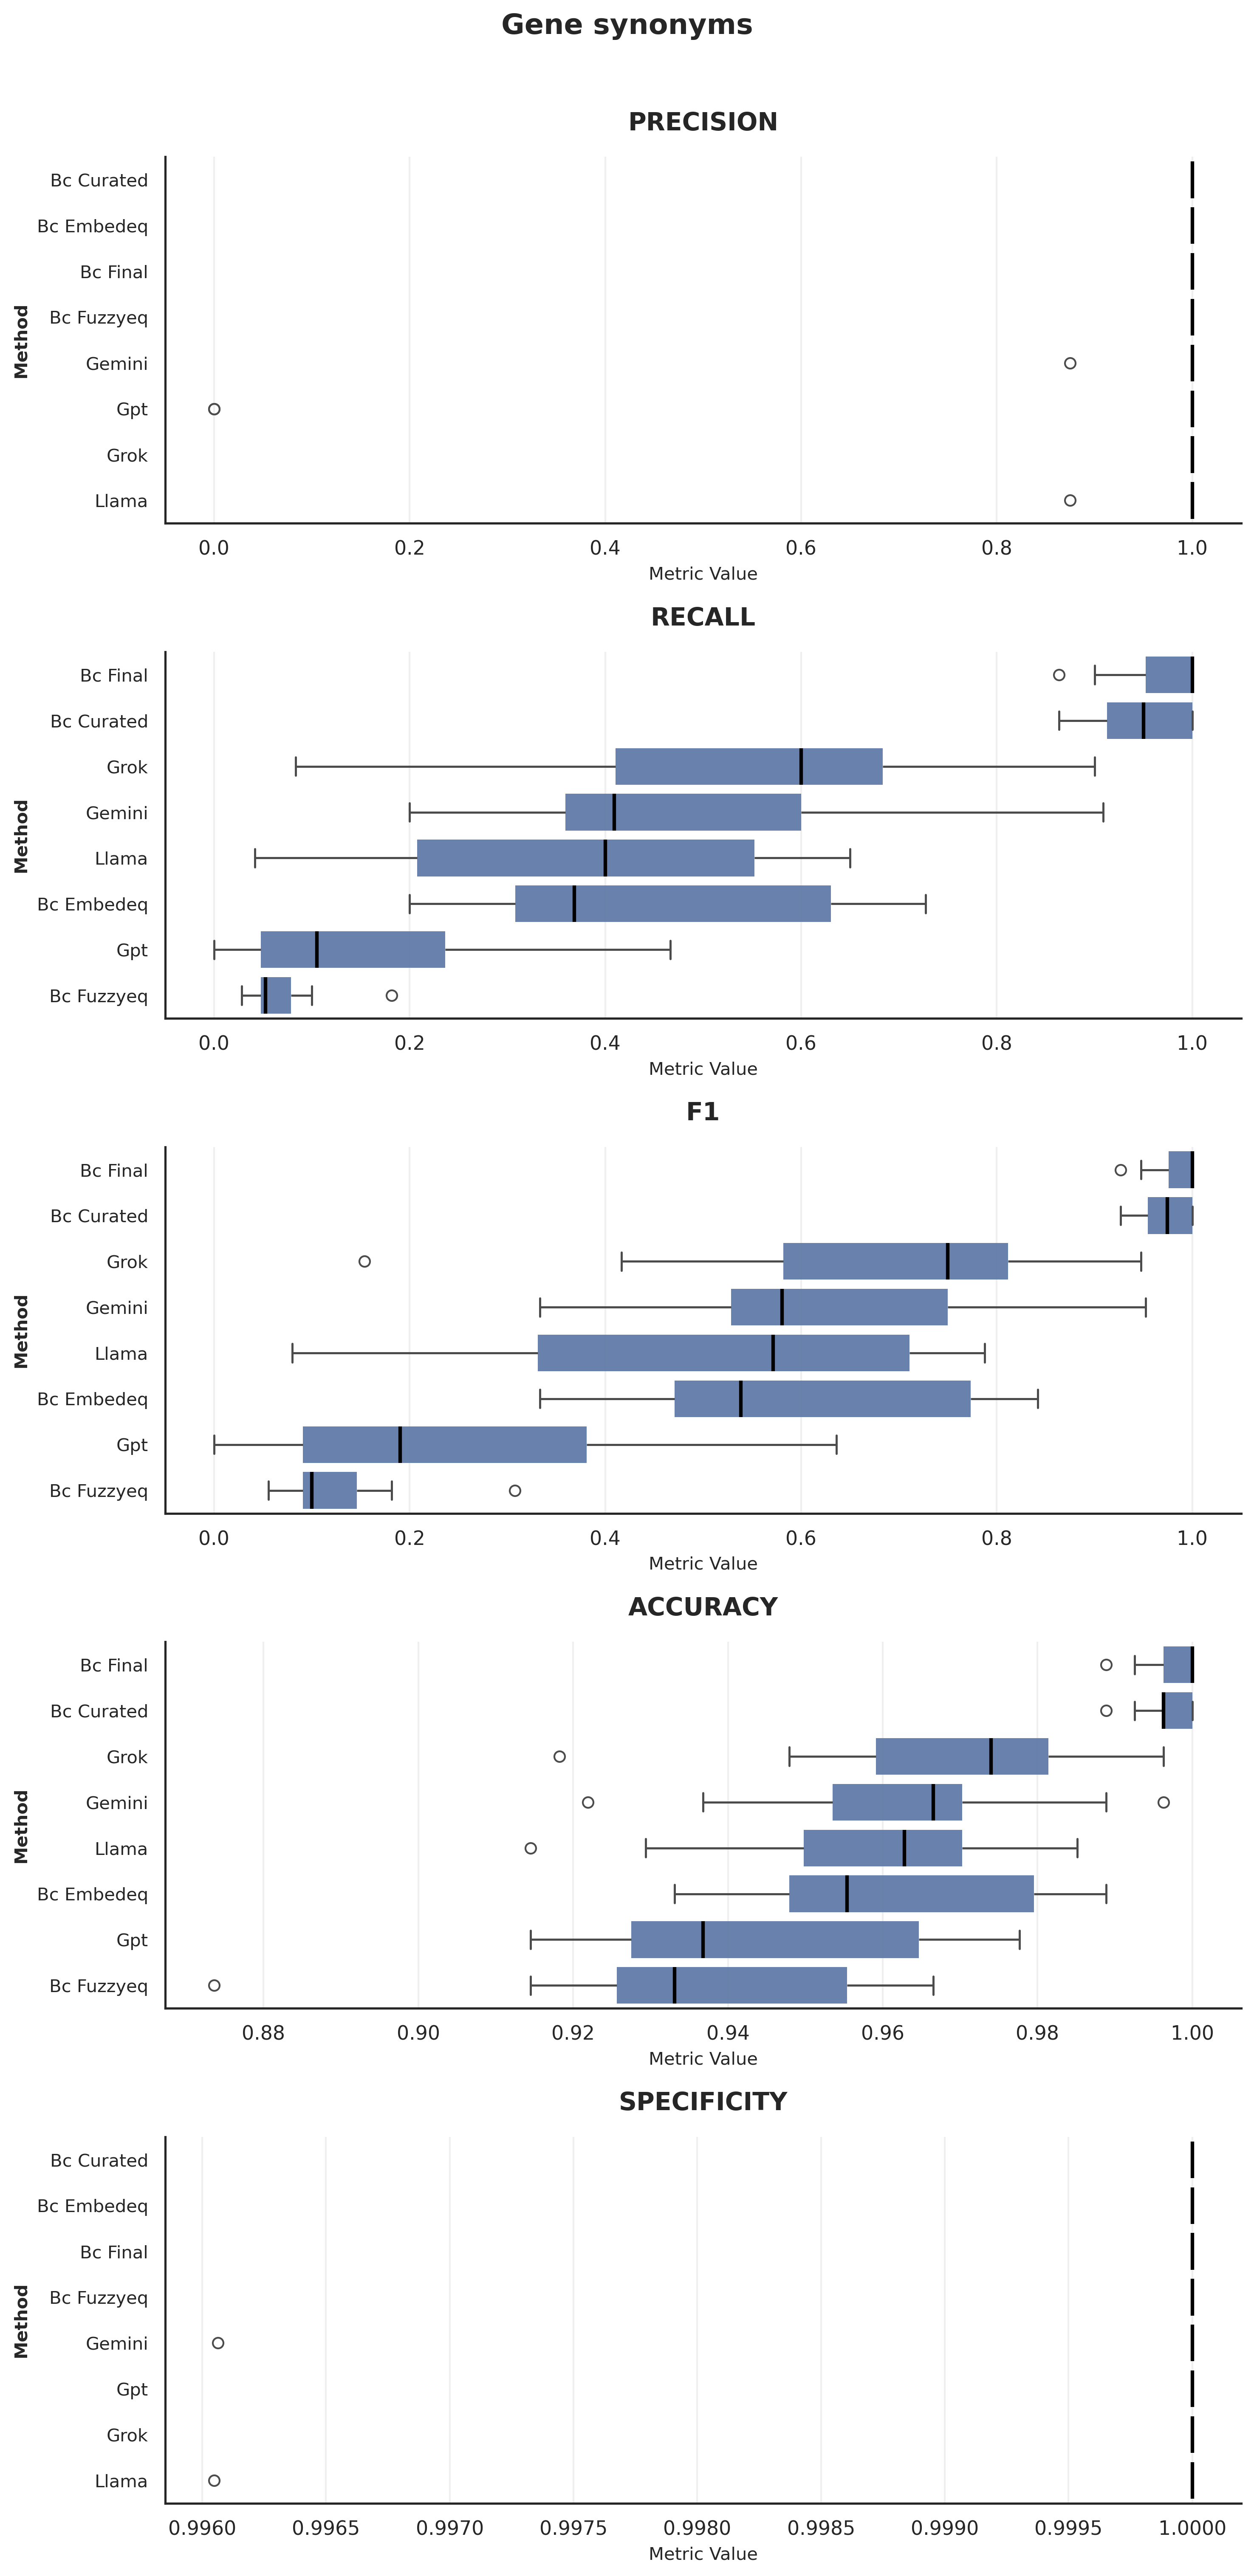

In [ ]:

# -----------------------------
# 2) Plot stacked boxplots (exact style like your snippet)
# -----------------------------
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"

metrics = ["precision", "recall", "f1", "accuracy", "specificity"]
ncols = 1
nrows = len(metrics)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows), dpi=300)
axes = np.array(axes).flatten()

brand_blue = "#4C72B0"

for i, metric in enumerate(metrics):
    ax = axes[i]
    metric_df = df[df["metric"] == metric]

    # 
    # 
    #  methods by median (desc)
    order = (
        metric_df.groupby("method")["value"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=metric_df,
        x="value",
        y="method",
        order=order,
        ax=ax,
        color=brand_blue,
        linewidth=1.2,
        showfliers=True,
        showcaps=True,
        boxprops={"edgecolor": "none", "alpha": 0.9},
        medianprops={"color": "black", "linewidth": 2},
    )

    ax.set_title(metric.upper(), fontsize=14, fontweight="bold", loc="center", pad=15)
    ax.set_xlabel("Metric Value", fontsize=10)
    ax.set_ylabel("Method", fontsize=10, fontweight="bold")

    labels = [l.get_text().replace("-", " ").title() for l in ax.get_yticklabels()]
    ax.set_yticklabels(labels, fontsize=10)

    sns.despine(ax=ax, left=False, bottom=False)
    ax.xaxis.grid(True, linestyle="-", alpha=0.3)
    ax.yaxis.grid(False)

fig.suptitle("Gene synonyms", fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()